## 4. Fig. 3 is a photo of a woman standing in front of an open window. Convert this to grayscale.

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [3]:
f = cv.imread(r'C:\Users\94775\Desktop\msc\Semester III\Computer Vision\258764G\woman_standing.jpg', cv.IMREAD_GRAYSCALE)
assert f is not None, 'Image not found'

(a) Use Otsu thesholding to obtain the binary mask for the foreground comprising the woman and the room. Report the resulting threshold value.

In [9]:
thresh_val, binary_mask = cv.threshold(
    f, 0, 255,
    cv.THRESH_BINARY + cv.THRESH_OTSU   
)

In [5]:
print(f'Otsu Threshold Value: {thresh_val}')

Otsu Threshold Value: 101.0


(b) Carry out histogram equalization only for the foreground region. What are the hidden features that are revealed in the resulting image

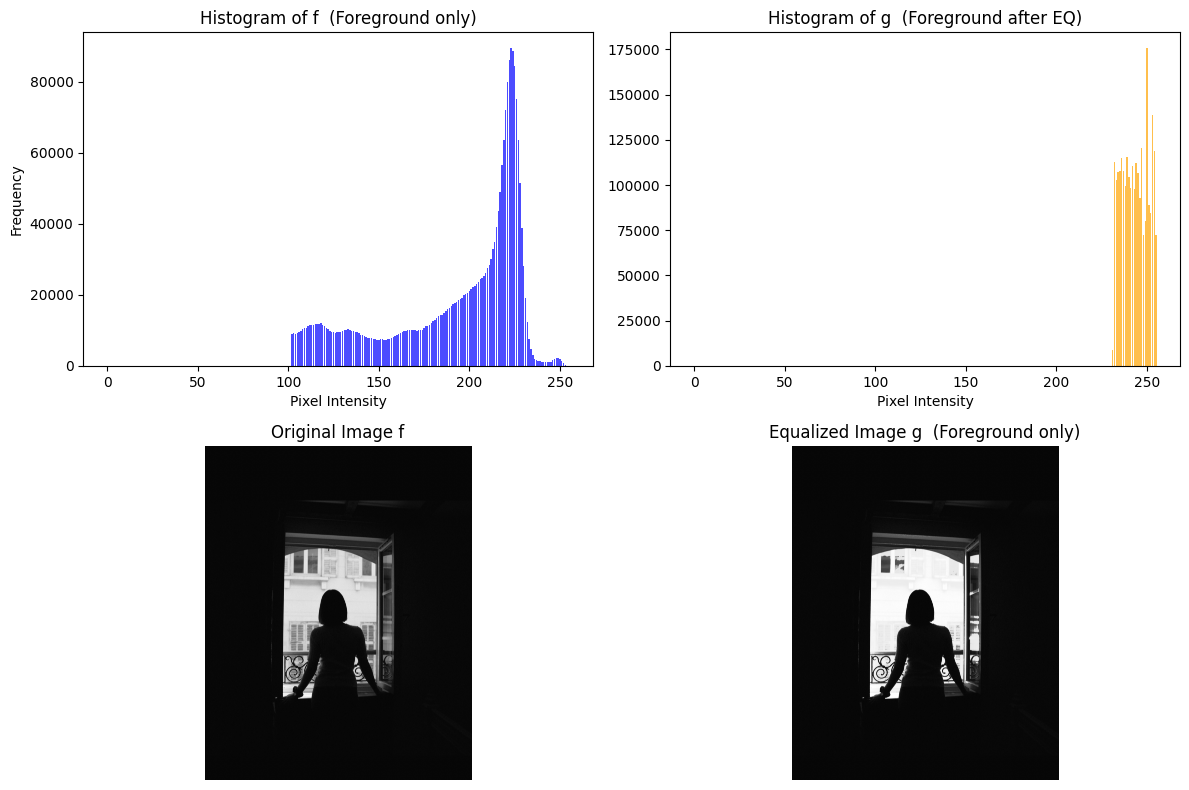

In [8]:
hist_f = cv.calcHist([f], [0], binary_mask, [256], [0, 256]).flatten()
g_eq = cv.equalizeHist(f)               # equalize whole image
g = f.copy()
g[binary_mask == 255] = g_eq[binary_mask == 255]
hist_g = cv.calcHist([g], [0], binary_mask, [256], [0, 256]).flatten()
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax[0, 0].bar(range(256), hist_f, color='blue', alpha=0.7)
ax[0, 0].set_title('Histogram of f  (Foreground only)')
ax[0, 0].set_xlabel('Pixel Intensity')
ax[0, 0].set_ylabel('Frequency')
ax[0, 1].bar(range(256), hist_g, color='orange', alpha=0.7)
ax[0, 1].set_title('Histogram of g  (Foreground after EQ)')
ax[0, 1].set_xlabel('Pixel Intensity')
ax[1, 0].imshow(f, cmap='gray', vmin=0, vmax=255)
ax[1, 0].set_title('Original Image f')
ax[1, 0].axis('off')
ax[1, 1].imshow(g, cmap='gray', vmin=0, vmax=255)
ax[1, 1].set_title('Equalized Image g  (Foreground only)')
ax[1, 1].axis('off')
plt.tight_layout()
plt.show()

---

## 5. Gaussian filtering:


(a) Using NumPy, compute a normalized 5×5 Gaussian kernel for σ = 2.

In [10]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [11]:
h_size = 2          
 
x = np.arange(-h_size, h_size + 1, 1)
y = np.arange(-h_size, h_size + 1, 1)
Y, X = np.meshgrid(x, y)

print(X)
print(Y)

[[-2 -2 -2 -2 -2]
 [-1 -1 -1 -1 -1]
 [ 0  0  0  0  0]
 [ 1  1  1  1  1]
 [ 2  2  2  2  2]]
[[-2 -1  0  1  2]
 [-2 -1  0  1  2]
 [-2 -1  0  1  2]
 [-2 -1  0  1  2]
 [-2 -1  0  1  2]]


In [13]:
sigma = 2
g_5x5 = 1 / (2 * np.pi * sigma**2) * np.exp(-(X**2 + Y**2) / (2 * sigma**2))
g_5x5 = g_5x5 / np.sum(g_5x5)

(b) Visualize a 51×51 computed Gaussian kernel as a 3D surface plot, where the kernel coefficients represent the height.

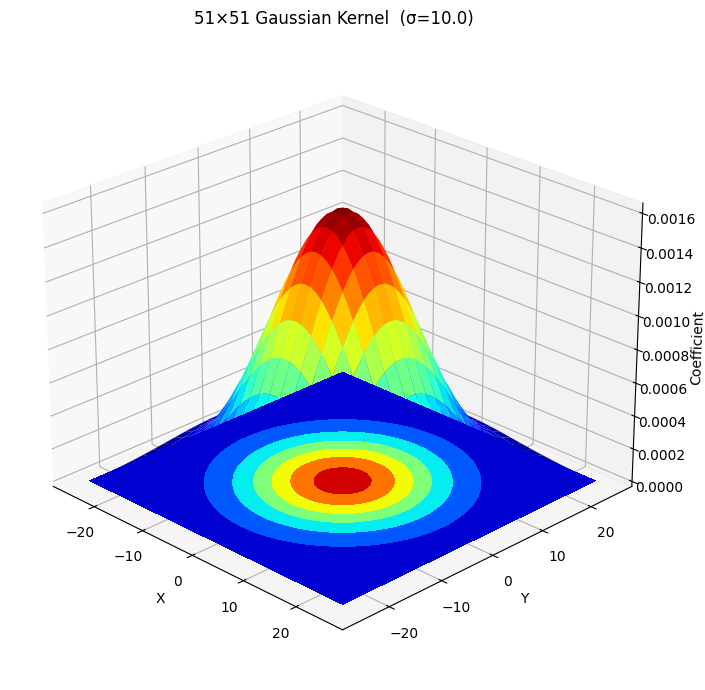

In [18]:
h_size_big = 25     
sigma_big  = 10.0  
 
x_big = np.arange(-h_size_big, h_size_big + 1, 1)
y_big = np.arange(-h_size_big, h_size_big + 1, 1)
Y_big, X_big = np.meshgrid(x_big, y_big)
 
g_51x51 = 1 / (2 * np.pi * sigma_big**2) * np.exp(-(X_big**2 + Y_big**2) / (2 * sigma_big**2))
g_51x51 = g_51x51 / np.sum(g_51x51)
 
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X_big, Y_big, g_51x51, cmap='jet',
                rstride=2, cstride=2, linewidth=0.1, antialiased=True)
ax.contourf(X_big, Y_big, g_51x51, zdir='z', offset=g_51x51.min() * 1.5, cmap='jet')
ax.set_title(f'51×51 Gaussian Kernel  (σ={sigma_big})', fontsize=12)
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Coefficient')
ax.view_init(elev=25, azim=-45)
plt.tight_layout()
plt.show()

(c) Apply Gaussian smoothing to a given grayscale image using the manually computed Gaussian kernel.

In [25]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [26]:
f = cv.imread(r'C:\Users\94775\Desktop\msc\Semester III\Computer Vision\258764G\woman_standing.jpg', cv.IMREAD_GRAYSCALE)
assert f is not None, 'Image not found'

In [32]:
sigma_filt = 2
h_size_filt = 3 * sigma_filt
 
x_f = np.arange(-h_size_filt, h_size_filt + 1, 1)
y_f = np.arange(-h_size_filt, h_size_filt + 1, 1)
Y_f, X_f = np.meshgrid(x_f, y_f)
 
g = 1 / (2 * np.pi * sigma_filt**2) * np.exp(-(X_f**2 + Y_f**2) / (2 * sigma_filt**2))
g = g / np.sum(g)

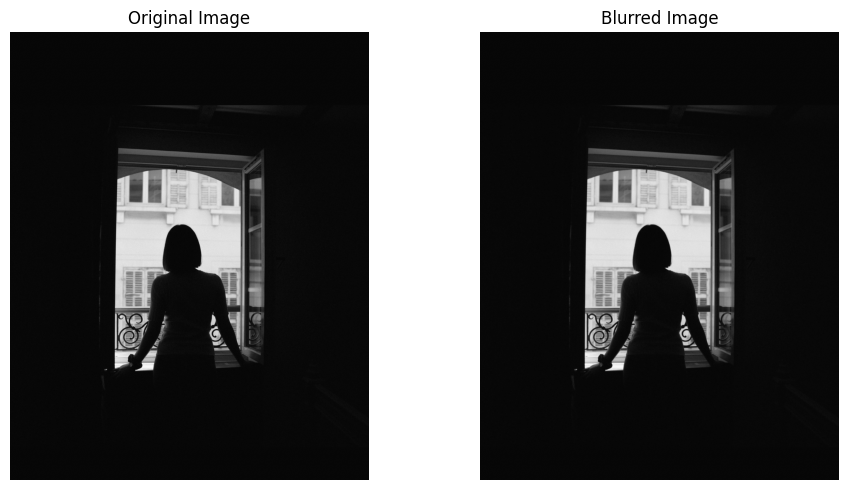

In [33]:
blurred = cv.filter2D (f, -1, g)
fig, ax = plt.subplots(1, 2, figsize=(10, 5)) 
ax[0].imshow(f, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Original Image')
ax[0].axis('off')
ax[1].imshow(blurred, cmap='gray', vmin=0, vmax=255)
ax[1].set_title('Blurred Image')
ax[1].axis('off')
plt.tight_layout()
plt.show()

(d) Do the same using OpenCV’s built-in cv.GaussianBlur() function.

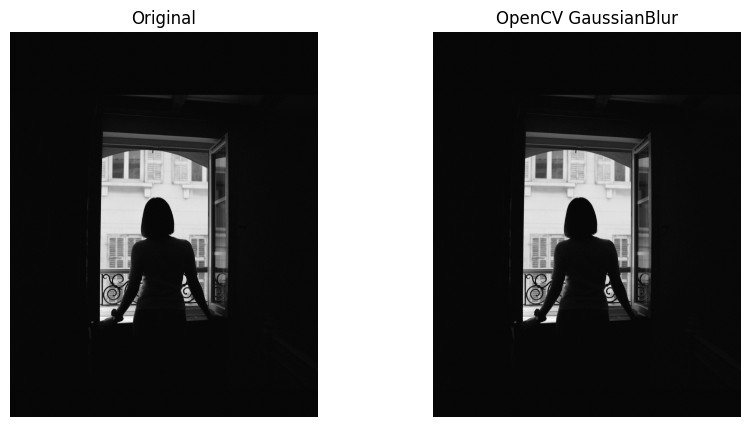

In [31]:
blurred_cv = cv.GaussianBlur(f, (5, 5), 2)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(f, cmap='gray', vmin=0, vmax=255)
plt.title('Original')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(blurred_cv, cmap='gray', vmin=0, vmax=255)
plt.title('OpenCV GaussianBlur')
plt.axis('off')

plt.show()